**🎓— Student Performance Predictor**

In [8]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [9]:
# Create student dataset
np.random.seed(42)

data = {
    "study_hours":    [2, 5, 1, 8, 3, 7, 4, 6, 1, 9,
                       3, 5, 2, 7, 4, 8, 1, 6, 3, 9,
                       2, 4, 6, 8, 1, 5, 3, 7, 2, 6],
    "attendance_pct": [60, 85, 50, 95, 65, 90, 70, 88, 45, 98,
                       62, 80, 55, 92, 68, 94, 48, 86, 64, 97,
                       58, 72, 84, 96, 46, 78, 66, 91, 54, 83],
    "prev_score":     [45, 72, 38, 88, 52, 81, 61, 76, 35, 93,
                       48, 69, 41, 85, 57, 90, 32, 78, 50, 91,
                       43, 63, 75, 89, 37, 71, 55, 84, 44, 74],
    "passed":         [0, 1, 0, 1, 0, 1, 1, 1, 0, 1,
                       0, 1, 0, 1, 1, 1, 0, 1, 0, 1,
                       0, 1, 1, 1, 0, 1, 0, 1, 0, 1]
}

df = pd.DataFrame(data)
print("Dataset shape:", df.shape)
print(df.head(10))

Dataset shape: (30, 4)
   study_hours  attendance_pct  prev_score  passed
0            2              60          45       0
1            5              85          72       1
2            1              50          38       0
3            8              95          88       1
4            3              65          52       0
5            7              90          81       1
6            4              70          61       1
7            6              88          76       1
8            1              45          35       0
9            9              98          93       1


In [10]:
# Basic statistics
print("=== Dataset Info ===")
print(df.describe())

print("\n=== Pass vs Fail Count ===")
print(df["passed"].value_counts())
print(f"\nPass rate: {df['passed'].mean() * 100:.1f}%")

=== Dataset Info ===
       study_hours  attendance_pct  prev_score     passed
count    30.000000       30.000000   30.000000  30.000000
mean      4.600000       74.000000   63.900000   0.600000
std       2.554239       17.148439   19.487131   0.498273
min       1.000000       45.000000   32.000000   0.000000
25%       2.250000       60.500000   45.750000   0.000000
50%       4.500000       75.000000   66.000000   1.000000
75%       6.750000       89.500000   80.250000   1.000000
max       9.000000       98.000000   93.000000   1.000000

=== Pass vs Fail Count ===
passed
1    18
0    12
Name: count, dtype: int64

Pass rate: 60.0%


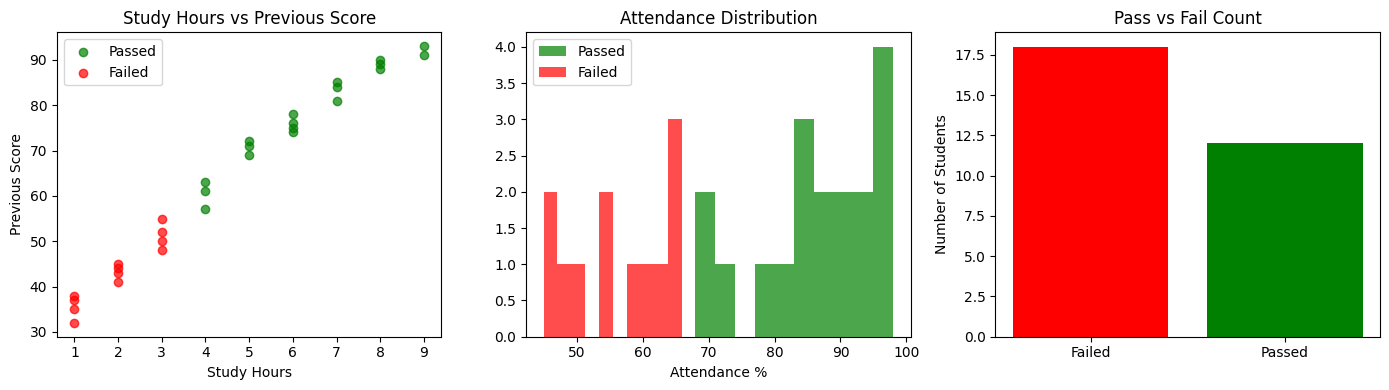

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Study hours vs result
axes[0].scatter(df[df["passed"]==1]["study_hours"],
                df[df["passed"]==1]["prev_score"],
                color="green", label="Passed", alpha=0.7)
axes[0].scatter(df[df["passed"]==0]["study_hours"],
                df[df["passed"]==0]["prev_score"],
                color="red", label="Failed", alpha=0.7)
axes[0].set_title("Study Hours vs Previous Score")
axes[0].set_xlabel("Study Hours")
axes[0].set_ylabel("Previous Score")
axes[0].legend()

# Attendance distribution
axes[1].hist(df[df["passed"]==1]["attendance_pct"],
             alpha=0.7, color="green", label="Passed")
axes[1].hist(df[df["passed"]==0]["attendance_pct"],
             alpha=0.7, color="red", label="Failed")
axes[1].set_title("Attendance Distribution")
axes[1].set_xlabel("Attendance %")
axes[1].legend()

# Pass vs Fail count
axes[2].bar(["Failed", "Passed"],
            df["passed"].value_counts().values,
            color=["red", "green"])
axes[2].set_title("Pass vs Fail Count")
axes[2].set_ylabel("Number of Students")

plt.tight_layout()
plt.show()

In [12]:
# Features and target
X = df[["study_hours", "attendance_pct", "prev_score"]]
y = df["passed"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LogisticRegression()
model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


=== Model Performance ===
Accuracy: 100.0%

=== Classification Report ===
              precision    recall  f1-score   support

      Failed       1.00      1.00      1.00         1
      Passed       1.00      1.00      1.00         5

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



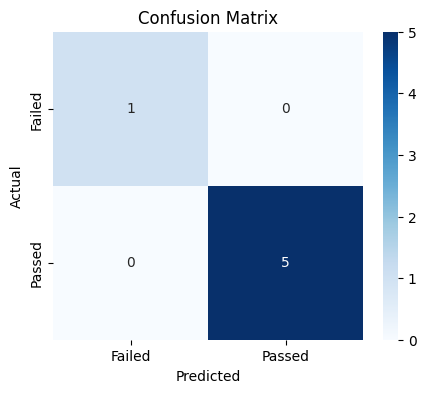

In [13]:
# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"=== Model Performance ===")
print(f"Accuracy: {accuracy * 100:.1f}%")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred,
      target_names=["Failed", "Passed"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d",
            cmap="Blues",
            xticklabels=["Failed", "Passed"],
            yticklabels=["Failed", "Passed"])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [14]:
def predict_student(study_hours, attendance, prev_score):
    input_data = pd.DataFrame({
        "study_hours": [study_hours],
        "attendance_pct": [attendance],
        "prev_score": [prev_score]
    })
    result = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0]

    print("=== Student Performance Prediction ===")
    print(f"Study Hours    : {study_hours} hrs/day")
    print(f"Attendance     : {attendance}%")
    print(f"Previous Score : {prev_score}/100")
    print(f"Pass Probability : {probability[1]*100:.1f}%")
    print(f"Result         : {'✅ PASS' if result == 1 else '❌ FAIL'}")

# Test predictions
predict_student(study_hours=6, attendance=85, prev_score=70)
print()
predict_student(study_hours=1, attendance=45, prev_score=35)

=== Student Performance Prediction ===
Study Hours    : 6 hrs/day
Attendance     : 85%
Previous Score : 70/100
Pass Probability : 100.0%
Result         : ✅ PASS

=== Student Performance Prediction ===
Study Hours    : 1 hrs/day
Attendance     : 45%
Previous Score : 35/100
Pass Probability : 0.0%
Result         : ❌ FAIL
